<a href="https://colab.research.google.com/github/shreyakrupesh/flight-EDA/blob/main/flight_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [7]:
data= pd.read_csv("/content/archive (3).zip")

Data Exploration and Data Cleaning

In [ ]:
data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
data.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
data.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [ ]:
data.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [ ]:
data.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [ ]:
data.groupby('airline')['price'].mean()

,price
airline,
AirAsia,4091.072742
Air_India,23507.019112
GO_FIRST,5652.007595
Indigo,5324.216303
SpiceJet,6179.278881
Vistara,30396.536302


In [ ]:

data.groupby('stops')['price'].mean()

,price
stops,
one,22900.992482
two_or_more,14113.450775
zero,9375.938535


In [ ]:
data.groupby('source_city')['price'].mean()

,price
source_city,
Bangalore,21469.460575
Chennai,21995.339871
Delhi,18951.326639
Hyderabad,20155.623879
Kolkata,21746.235679
Mumbai,21483.818839


In [ ]:
data.groupby('airline')['price'].mean().sort_values(ascending=False)

,price
airline,
Vistara,30396.536302
Air_India,23507.019112
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


Airline Distribution

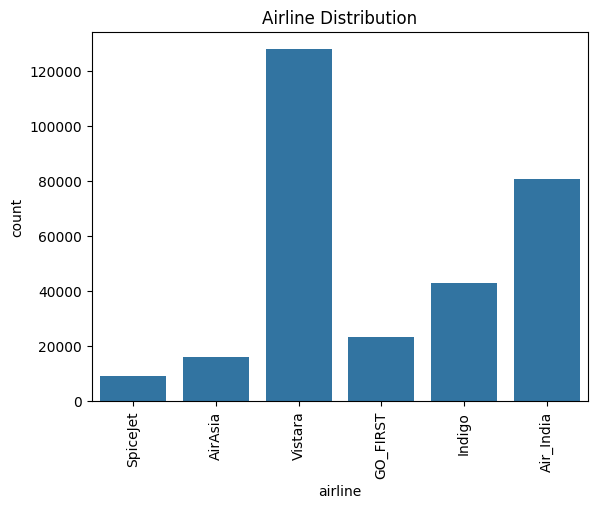

In [ ]:
sns.countplot(x='airline', data=data)
plt.xticks(rotation=90)
plt.title("Airline Distribution")
plt.show()

Price Distribution

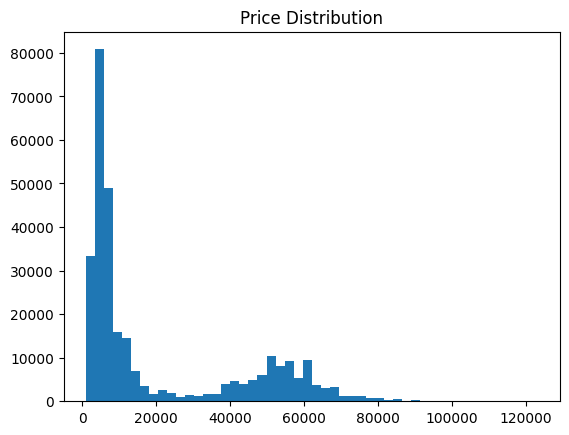

In [ ]:
plt.hist(data['price'], bins=50)
plt.title("Price Distribution")
plt.show()

Class distribution

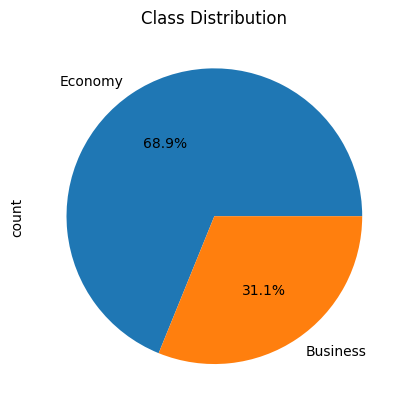

In [ ]:
data['class'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

Price vs Airline

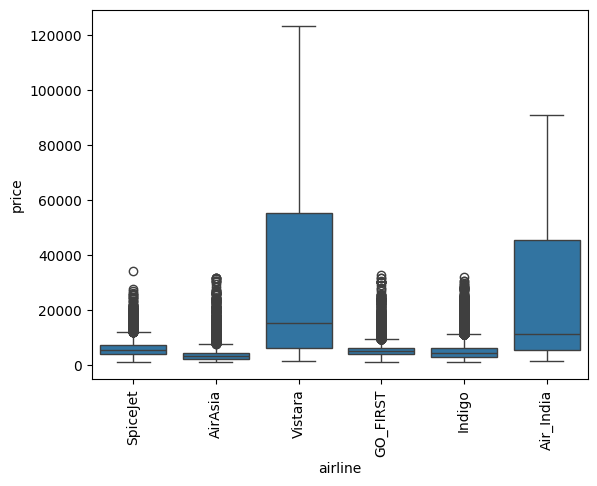

In [ ]:
sns.boxplot(x='airline', y='price', data=data)
plt.xticks(rotation=90)
plt.show()

Price vs Class

<Axes: xlabel='class', ylabel='price'>

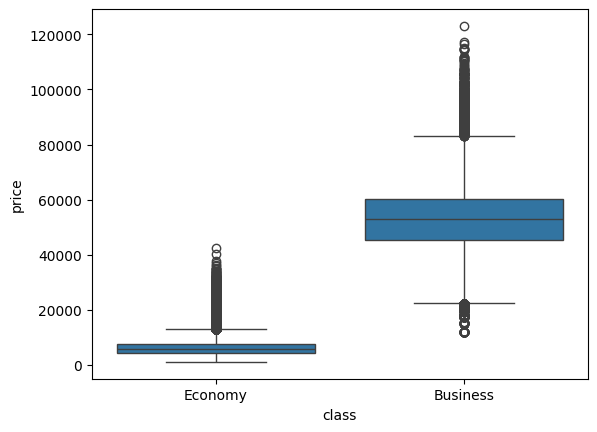

In [8]:
import seaborn as sns
sns.boxplot(x='class', y='price', data=data)

Price vs Days Left

<Axes: xlabel='days_left', ylabel='price'>

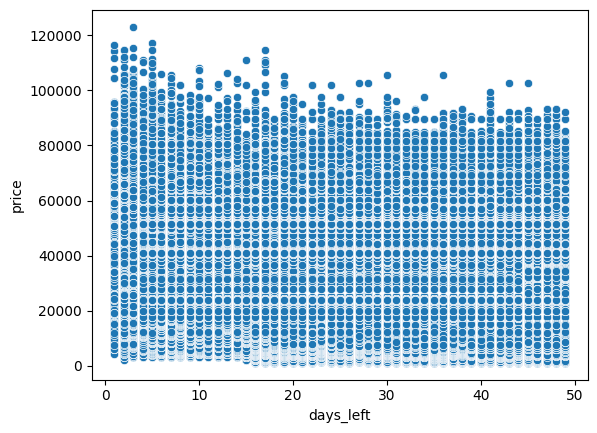

In [10]:
sns.scatterplot(x='days_left', y='price', data=data)

Stops vs Price

<Axes: xlabel='stops', ylabel='price'>

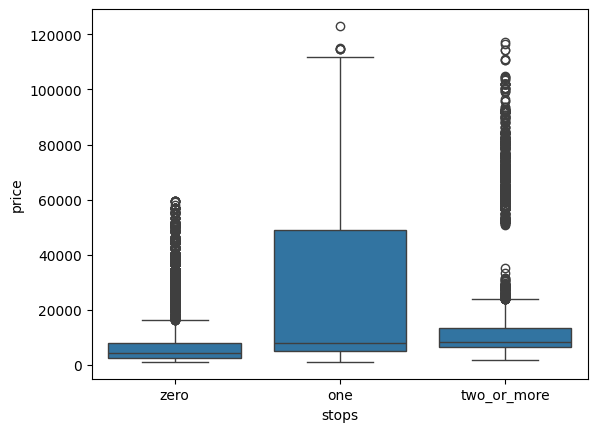

In [12]:
sns.boxplot(x='stops', y='price', data=data)

Destination Heatmap

<Axes: xlabel='destination_city', ylabel='source_city'>

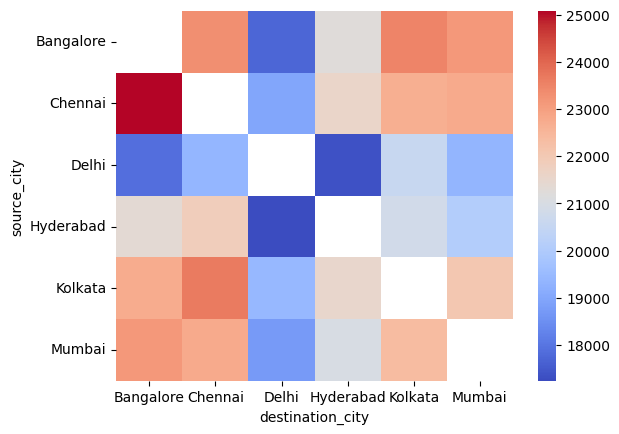

In [14]:
pivot = data.pivot_table(values='price',
                       index='source_city',
                       columns='destination_city')

sns.heatmap(pivot, cmap='coolwarm')

Airline + Class

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'SpiceJet'),
  Text(1, 0, 'AirAsia'),
  Text(2, 0, 'Vistara'),
  Text(3, 0, 'GO_FIRST'),
  Text(4, 0, 'Indigo'),
  Text(5, 0, 'Air_India')])

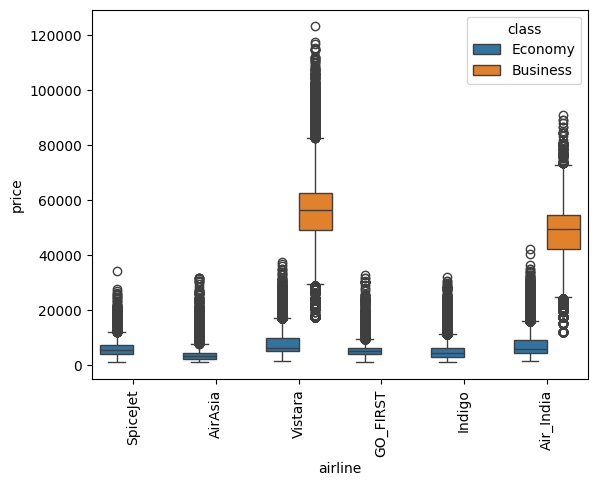

In [16]:
sns.boxplot(x='airline', y='price', hue='class', data=data)
plt.xticks(rotation=90)

Average price by airline

In [18]:
data.groupby('airline')['price'].mean().sort_values(ascending=False)

,price
airline,
Vistara,30396.536302
Air_India,23507.019112
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


Average price by route

In [19]:
data.groupby(['source_city','destination_city'])['price'].mean().sort_values(ascending=False).head(10)

source_city  destination_city
Chennai      Bangalore           25081.850454
Kolkata      Chennai             23660.361040
Bangalore    Kolkata             23500.061229
             Chennai             23321.850078
Mumbai       Bangalore           23147.873807
Bangalore    Mumbai              23128.618672
Mumbai       Chennai             22781.899112
Chennai      Mumbai              22765.849647
Kolkata      Bangalore           22744.808428
Chennai      Kolkata             22669.932407
Name: price, dtype: float64

Conclusion

This analysis shows that flight prices are influenced by multiple factors such as class, airline, booking time, and route. These insights can help customers book flights at lower prices and assist airlines in optimizing pricing strategies.